In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

col_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]

train_df = pd.read_csv('CMAPSSData/train_FD003.txt', sep=r'\s+', header=None, names=col_names, index_col=False)

def add_remaining_useful_life(df):
    max_cycle = df.groupby('id')['cycle'].transform('max')
    df['RUL'] = max_cycle - df['cycle']
    return df

train_df = add_remaining_useful_life(train_df)

In [4]:
# Drop sensors with zero variance (constant values)
relevant_sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
features = ['cycle', 'setting1', 'setting2'] + relevant_sensors

scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])

In [ ]:
def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield data_matrix[start:stop, :]

sequence_length = 30
seq_gen = (list(gen_sequence(train_df[train_df['id']==id], sequence_length, features)) 
           for id in train_df['id'].unique())

X_train = np.concatenate(list(seq_gen)).astype(np.float32)

def gen_labels(id_df, seq_length, label_col):
    data_matrix = id_df[label_col].values
    num_elements = data_matrix.shape[0]
    return data_matrix[seq_length:num_elements, :]

label_gen = [gen_labels(train_df[train_df['id']==id], sequence_length, ['RUL']) 
             for id in train_df['id'].unique()]
y_train = np.concatenate(label_gen).astype(np.float32)

print(f"Input Shape (Samples, Time Steps, Features): {X_train.shape}")

Input Shape (Samples, Time Steps, Features): (21720, 30, 17)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(sequence_length, len(features))),
    MaxPooling1D(pool_size=2),
    
    # LSTM Layer to learn the degradation over time
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    
    # Fully Connected Output
    Dense(1, activation='linear') 
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/Users/mukul/AI project/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-29 02:09:07.109334: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-29 02:09:07.109360: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-29 02:09:07.109365: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-29 02:09:07.109376: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-29 02:09:07.109384: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factor

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 100)        │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,579 (388.98 KB)

 Trainable params: 99,579 (388.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


2026-04-29 02:09:24.351402: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


306/306 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 19977.4570 - val_loss: 23632.4980
Epoch 2/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 16845.5254 - val_loss: 20737.9375
Epoch 3/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 14522.3691 - val_loss: 18443.1445
Epoch 4/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 12711.0518 - val_loss: 16640.6289
Epoch 5/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 11331.6416 - val_loss: 15249.5879
Epoch 6/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 10328.7344 - val_loss: 14204.8711
Epoch 7/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 9625.4238 - val_loss: 13439.0244
Epoch 8/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 9118.2256 - val_loss: 12901.1943
Epoch 9/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 8808.0459 - val_loss: 12533.8125
Epoch 10/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 8608.8271 - val_loss: 12294.5361
Epoch 11/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 85

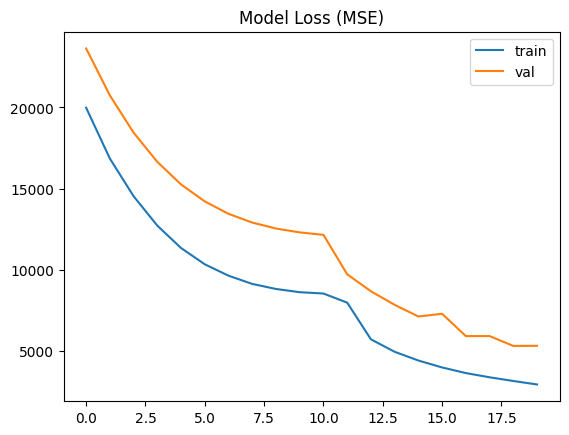

In [7]:
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1)

# Plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss (MSE)')
plt.legend()
plt.show()

In [18]:

test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep=r'\s+', header=None, names=col_names)
true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

# We only want the LAST sequence for each engine to predict its current RUL
def get_last_sequence(df, seq_length, seq_cols):
    last_seq = []
    for engine_id in df['id'].unique():
        engine_data = df[df['id'] == engine_id]
        if len(engine_data) >= seq_length:
            last_seq.append(engine_data[seq_cols].values[-seq_length:])
        else:
            # Pad if the engine trajectory is too short
            padding = np.zeros((seq_length - len(engine_data), len(seq_cols)))
            last_seq.append(np.vstack((padding, engine_data[seq_cols].values)))
    return np.array(last_seq)

X_test = get_last_sequence(test_df, sequence_length, features)
y_test = true_rul['RUL'].values

# Predict
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [2]:

test_df[features] = scaler.transform(test_df[features]) 

X_test = get_last_sequence(test_df, sequence_length, features)

y_pred = model.predict(X_test)

plt.figure(figsize=(15, 6))
plt.plot(y_test, color='red', label='Actual RUL', marker='o')
plt.plot(y_pred, color='blue', label='Predicted RUL', marker='x')
plt.title('Predictive Maintenance: Corrected Test Performance')
plt.legend()
plt.show()

NameError: name 'scaler' is not defined

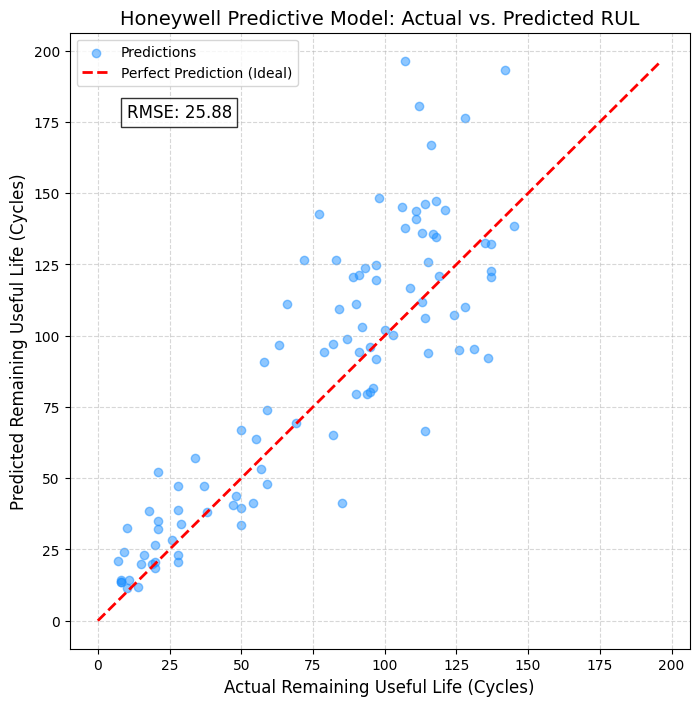

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='dodgerblue', label='Predictions')

limit = max(max(y_test.flatten()), max(y_pred.flatten()))
plt.plot([0, limit], [0, limit], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (Ideal)')

plt.title('Honeywell Predictive Model: Actual vs. Predicted RUL', fontsize=14)
plt.xlabel('Actual Remaining Useful Life (Cycles)', fontsize=12)
plt.ylabel('Predicted Remaining Useful Life (Cycles)', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
plt.text(10, limit-20, f'RMSE: {rmse:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

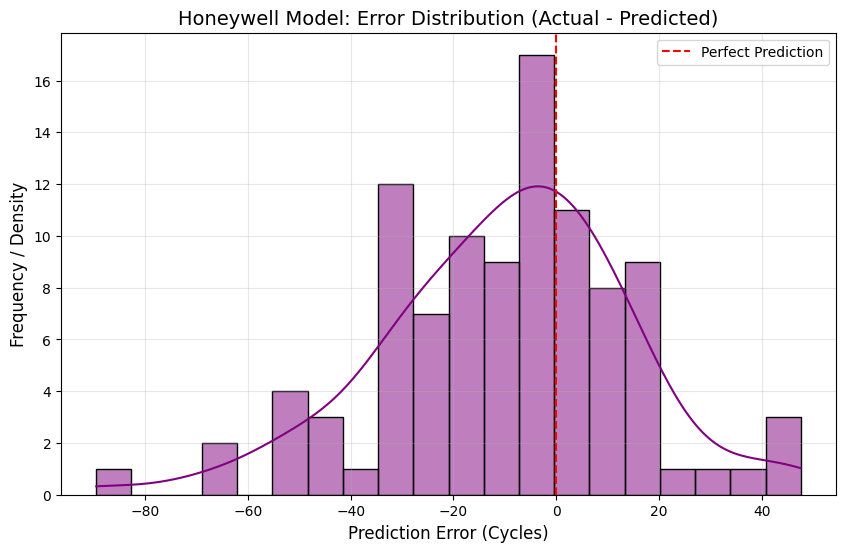

Mean Error: -9.95 cycles
Error Standard Deviation: 23.89 cycles


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

errors = y_test.flatten() - y_pred.flatten()

plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, color='purple', bins=20)

plt.axvline(x=0, color='red', linestyle='--', label='Perfect Prediction')

plt.title('Honeywell Model: Error Distribution (Actual - Predicted)', fontsize=14)
plt.xlabel('Prediction Error (Cycles)', fontsize=12)
plt.ylabel('Frequency / Density', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Mean Error: {errors.mean():.2f} cycles")
print(f"Error Standard Deviation: {errors.std():.2f} cycles")

In [10]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final Model RMSE: {rmse:.2f}")

Final Model RMSE: 25.88


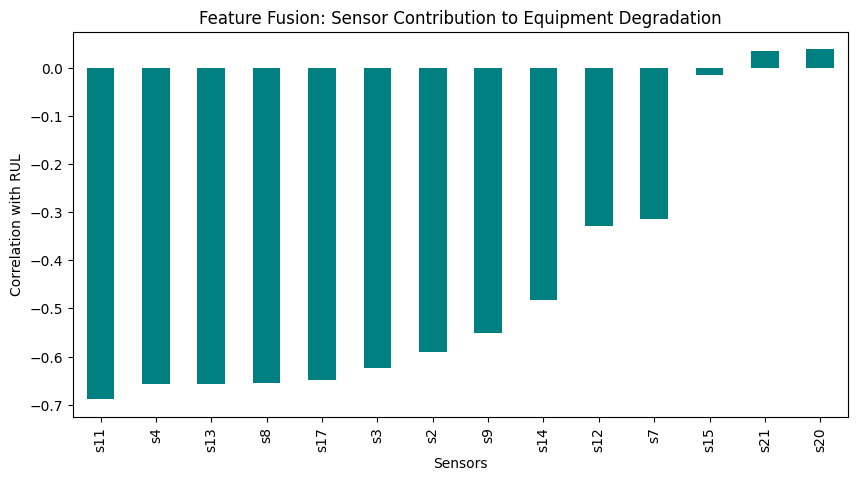

Top 3 Critical Sensors for Real-time Monitoring: s11, s4, s13


In [ ]:
import seaborn as sns

correlations = train_df[relevant_sensors + ['RUL']].corr()['RUL'].sort_values()

plt.figure(figsize=(10, 5))
correlations.drop('RUL').plot(kind='bar', color='teal')
plt.title('Feature Fusion: Sensor Contribution to Equipment Degradation')
plt.ylabel('Correlation with RUL')
plt.xlabel('Sensors')
plt.show()

print(f"Top 3 Critical Sensors for Real-time Monitoring: {correlations.index[0]}, {correlations.index[1]}, {correlations.index[2]}")

In [1]:
# 1. Smooth the predictions (Moving Average)
smoothed_pred = pd.Series(y_pred.flatten()).rolling(window=5, min_periods=1).mean()

# 2. Logic: Only trigger an alarm if RUL < 30 for 3 consecutive cycles (Persistence)
def detect_anomalies(predictions, threshold=30, persistence=5):
    alarms = []
    counter = 0
    for val in predictions:
        if val < threshold:
            counter += 1
        else:
            counter = 0
        
        if counter >= persistence:
            alarms.append("MAINTENANCE_REQUIRED")
        else:
            alarms.append("NORMAL")
    return alarms

test_df_results = pd.DataFrame({'Actual_RUL': y_test, 'Predicted_RUL': smoothed_pred})
test_df_results['Status'] = detect_anomalies(smoothed_pred)

print(test_df_results['Status'].value_counts())

NameError: name 'pd' is not defined

In [ ]:

dashboard = pd.DataFrame({
    'Engine_Unit': range(1, len(y_pred) + 1),
    'Predicted_RUL': y_pred.flatten().astype(int),
    'Priority': ''
})

dashboard.loc[dashboard['Predicted_RUL'] <= 20, 'Priority'] = '1 - URGENT (Failure Imminent)'
dashboard.loc[(dashboard['Predicted_RUL'] > 20) & (dashboard['Predicted_RUL'] <= 50), 'Priority'] = '2 - MEDIUM (Schedule Soon)'
dashboard.loc[dashboard['Predicted_RUL'] > 50, 'Priority'] = '3 - LOW (Healthy)'

priority_queue = dashboard.sort_values(by='Predicted_RUL').head(25)

print("MAINTENANCE PRIORITY QUEUE")
print(priority_queue[['Engine_Unit', 'Predicted_RUL', 'Priority']].to_string(index=False))

MAINTENANCE PRIORITY QUEUE
 Engine_Unit  Predicted_RUL                      Priority
          66             11 1 - URGENT (Failure Imminent)
          76             11 1 - URGENT (Failure Imminent)
          68             13 1 - URGENT (Failure Imminent)
          31             13 1 - URGENT (Failure Imminent)
          35             14 1 - URGENT (Failure Imminent)
          81             14 1 - URGENT (Failure Imminent)
         100             18 1 - URGENT (Failure Imminent)
          36             19 1 - URGENT (Failure Imminent)
          90             20 1 - URGENT (Failure Imminent)
          34             20 1 - URGENT (Failure Imminent)
          56             20 1 - URGENT (Failure Imminent)
          24             20 1 - URGENT (Failure Imminent)
          40             23    2 - MEDIUM (Schedule Soon)
          20             23    2 - MEDIUM (Schedule Soon)
          82             24    2 - MEDIUM (Schedule Soon)
          92             26    2 - MEDIUM (Sc